# Flight Delay Prediction
### Sam Turbeville
### Intro to Machine Learning — Final Project

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

We load the dataset from flights.csv, downloaded from Kaggle. The dataset contains 
5.8 million flights from 2015 with 31 features.

Note: Columns 7 and 8 contain mixed data types, causing a DtypeWarning on load. 
We will resolve this during preprocessing by converting the affected columns to strings.

In [22]:
df = pd.read_csv('flights.csv')
print(df.shape)
print(df.head())
print(df.dtypes)

/var/folders/7n/z__t062x76z5pxnjhw4r706h0000gn/T/ipykernel_73205/1114884937.py:1: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('flights.csv')


(5819079, 31)
   YEAR  MONTH  DAY  DAY_OF_WEEK AIRLINE  FLIGHT_NUMBER TAIL_NUMBER  \
0  2015      1    1            4      AS             98      N407AS   
1  2015      1    1            4      AA           2336      N3KUAA   
2  2015      1    1            4      US            840      N171US   
3  2015      1    1            4      AA            258      N3HYAA   
4  2015      1    1            4      AS            135      N527AS   

  ORIGIN_AIRPORT DESTINATION_AIRPORT  SCHEDULED_DEPARTURE  ...  ARRIVAL_TIME  \
0            ANC                 SEA                    5  ...         408.0   
1            LAX                 PBI                   10  ...         741.0   
2            SFO                 CLT                   20  ...         811.0   
3            LAX                 MIA                   20  ...         756.0   
4            SEA                 ANC                   25  ...         259.0   

   ARRIVAL_DELAY  DIVERTED  CANCELLED  CANCELLATION_REASON  AIR_SYSTEM_DELAY  

## Data Exploration

We examine the dataset for missing values, basic statistics, and class distribution.

Delay-related features such as AIR_SYSTEM_DELAY and WEATHER_DELAY are NaN for on-time 
flights — this is expected, not missing data, since these fields are only populated when 
a delay occurs. Cancelled and diverted flights account for the remaining NaN values in 
ARRIVAL_DELAY and are removed from the dataset since they do not have a meaningful 
arrival delay value.

We use the FAA's official definition of a delay — 15 or more minutes late — as our 
binary target variable. After removing cancelled and diverted flights, 18.6% of flights 
in the dataset are classified as delayed.

In [23]:
# Check missing values
print("Missing values per column:")
print(df.isnull().sum())

print("\nBasic stats on ARRIVAL_DELAY:")
print(df['ARRIVAL_DELAY'].describe())

print("\nCancelled flights:", df['CANCELLED'].sum())
print("Diverted flights:", df['DIVERTED'].sum())

Missing values per column:
YEAR                         0
MONTH                        0
DAY                          0
DAY_OF_WEEK                  0
AIRLINE                      0
FLIGHT_NUMBER                0
TAIL_NUMBER              14721
ORIGIN_AIRPORT               0
DESTINATION_AIRPORT          0
SCHEDULED_DEPARTURE          0
DEPARTURE_TIME           86153
DEPARTURE_DELAY          86153
TAXI_OUT                 89047
WHEELS_OFF               89047
SCHEDULED_TIME               6
ELAPSED_TIME            105071
AIR_TIME                105071
DISTANCE                     0
WHEELS_ON                92513
TAXI_IN                  92513
SCHEDULED_ARRIVAL            0
ARRIVAL_TIME             92513
ARRIVAL_DELAY           105071
DIVERTED                     0
CANCELLED                    0
CANCELLATION_REASON    5729195
AIR_SYSTEM_DELAY       4755640
SECURITY_DELAY         4755640
AIRLINE_DELAY          4755640
LATE_AIRCRAFT_DELAY    4755640
WEATHER_DELAY          4755640
dtype: int64

In [24]:
# Drop cancelled and diverted flights
df_clean = df[(df['CANCELLED'] == 0) & (df['DIVERTED'] == 0)].copy()

# Create binary target variable: 1 if delayed by 15+ minutes, 0 otherwise
# 15 minutes is the FAA's official definition of a delay
df_clean['IS_DELAYED'] = (df_clean['ARRIVAL_DELAY'] >= 15).astype(int)

print("Dataset size after removing cancelled/diverted:", df_clean.shape)
print("\nDelay distribution:")
print(df_clean['IS_DELAYED'].value_counts())
print("\nDelay rate: {:.1f}%".format(df_clean['IS_DELAYED'].mean() * 100))

Dataset size after removing cancelled/diverted: (5714008, 32)

Delay distribution:
IS_DELAYED
0    4650569
1    1063439
Name: count, dtype: int64

Delay rate: 18.6%


## Sampling

The full dataset contains 5.7 million rows, which would make model training 
computationally expensive. We take a stratified random sample of 100,000 flights, 
preserving the original 18.6% delay rate across the sample.

We also fix the mixed type issue in AIRLINE, ORIGIN_AIRPORT, and DESTINATION_AIRPORT 
by converting these columns to strings before any further processing.

In [25]:
from sklearn.model_selection import train_test_split

# Stratified sample of 100k rows
df_sample, _ = train_test_split(
    df_clean,
    train_size=100000,
    stratify=df_clean['IS_DELAYED'],
    random_state=42
)

print("Sample shape:", df_sample.shape)
print("\nDelay distribution in sample:")
print(df_sample['IS_DELAYED'].value_counts())
print("\nDelay rate in sample: {:.1f}%".format(df_sample['IS_DELAYED'].mean() * 100))

Sample shape: (100000, 32)

Delay distribution in sample:
IS_DELAYED
0    81389
1    18611
Name: count, dtype: int64

Delay rate in sample: 18.6%


In [26]:
# Fix mixed types in airport and airline columns
for col in ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']:
    df_sample[col] = df_sample[col].astype(str)


## Data Exploration & Visualization

We generate four visualizations to explore patterns in flight delays across airlines, 
months, days of the week, and arrival time distributions.

- **Delay Rate by Airline:** Spirit Airlines has the highest delay rate of all airlines 
in the dataset, while Hawaiian Airlines has the lowest, performing significantly better 
than all other carriers.

- **Delay Rate by Month:** We observe spikes in flight delays in February, June, and 
December. These likely correspond to winter weather disruptions in February and December, 
and increased summer travel volume in June. September and October have notably lower 
delay rates.

- **Delay Rate by Day of Week:** Delay rates are fairly consistent across all days of 
the week, hovering between 16-20%. Thursday is the highest at approximately 22%, though 
most other days are close behind.

- **Arrival Delay Distribution (Non-Delayed Flights):** The distribution is roughly 
bell-shaped and centered slightly below zero, meaning most on-time flights actually 
arrive a few minutes early.

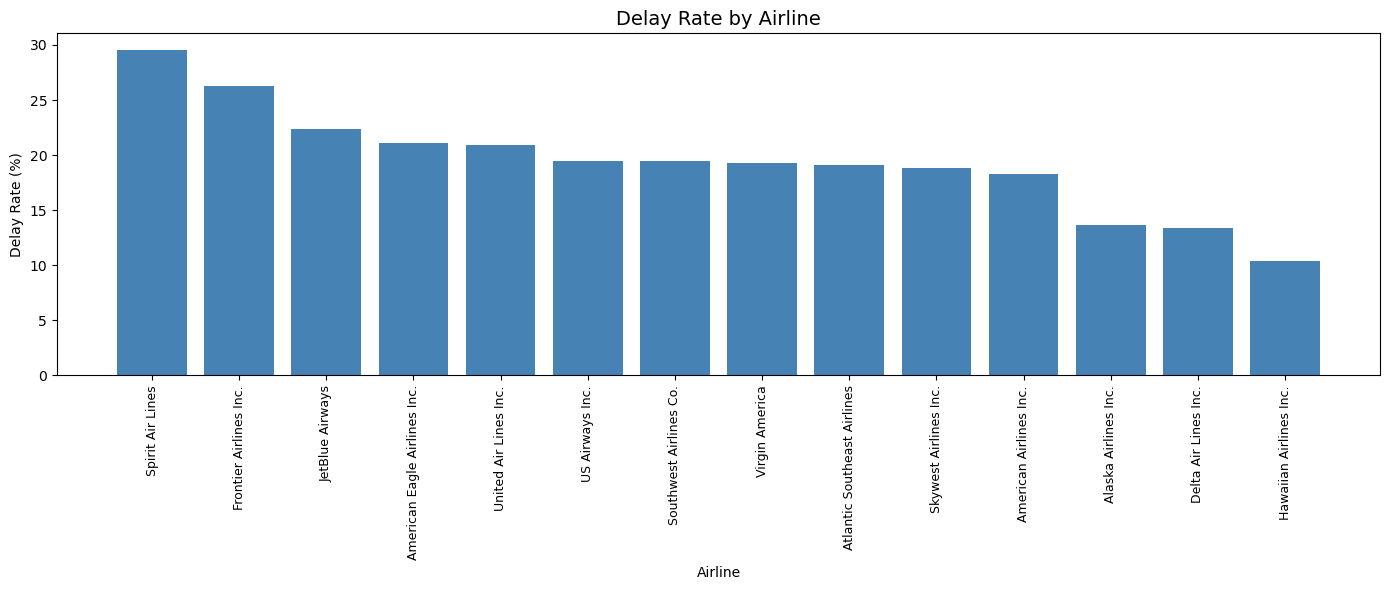

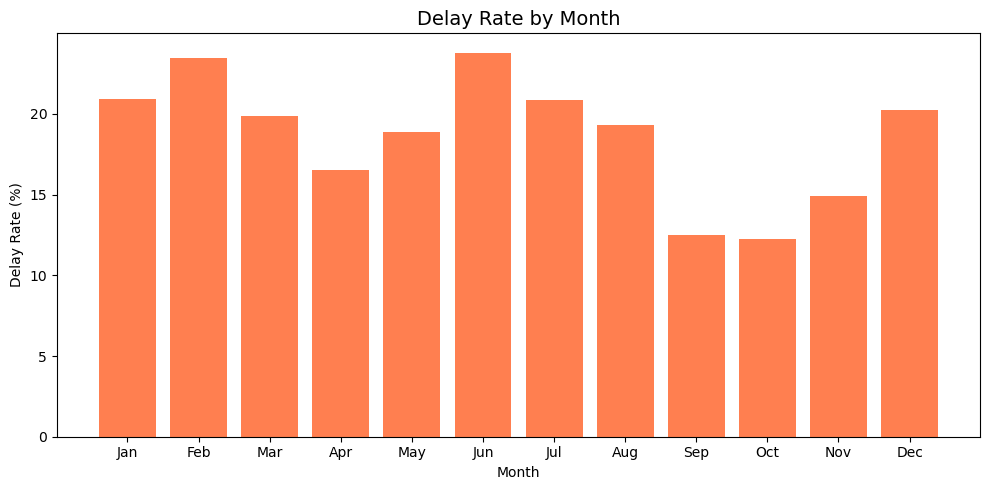

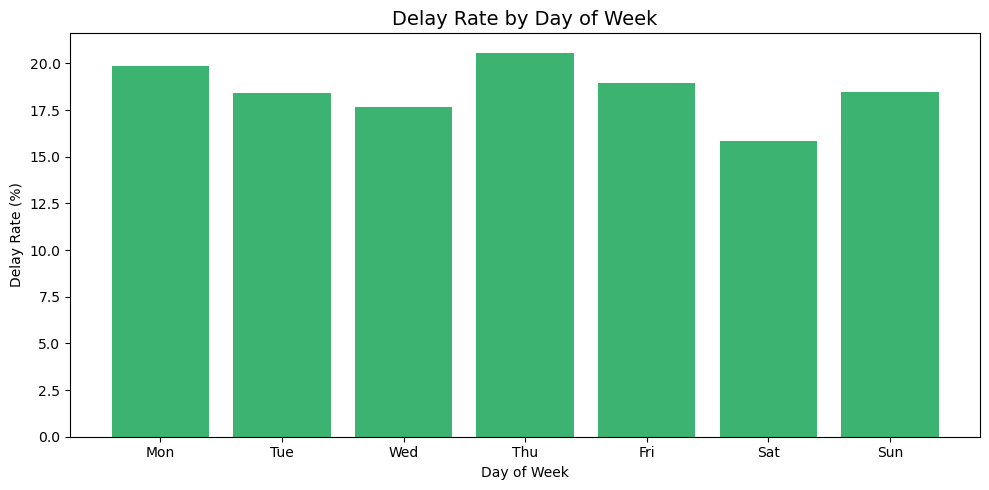

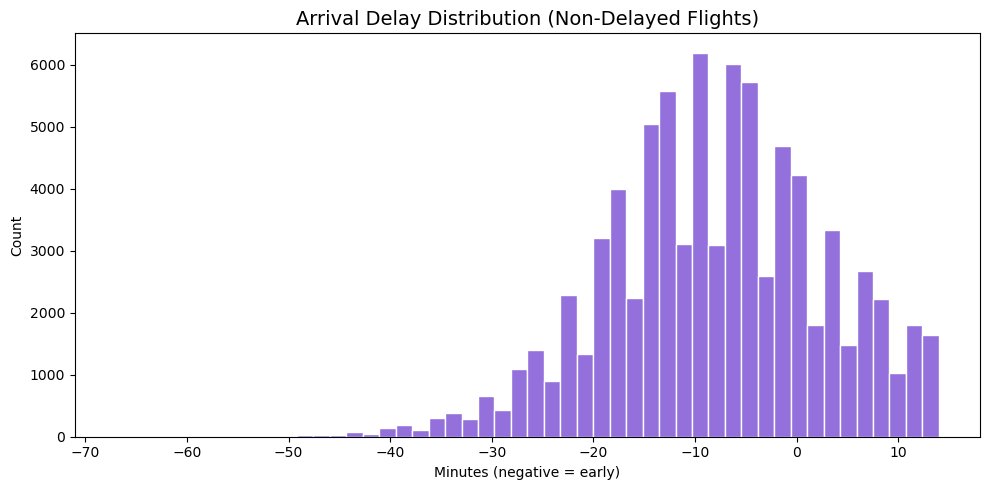

All 4 plots saved!


In [27]:
# Load airline names for readable labels
airlines_df = pd.read_csv('airlines.csv')
airline_map = dict(zip(airlines_df['IATA_CODE'], airlines_df['AIRLINE']))
df_sample['AIRLINE_NAME'] = df_sample['AIRLINE'].map(airline_map)

# ---- Plot 1: Delay rate by airline (fixed labels) ----
fig1, ax1 = plt.subplots(figsize=(14, 6))
airline_delay = df_sample.groupby('AIRLINE_NAME')['IS_DELAYED'].mean().sort_values(ascending=False)
ax1.bar(airline_delay.index, airline_delay.values * 100, color='steelblue')
ax1.set_title('Delay Rate by Airline', fontsize=14)
ax1.set_ylabel('Delay Rate (%)')
ax1.set_xlabel('Airline')
ax1.tick_params(axis='x', rotation=90, labelsize=9)
plt.tight_layout()
plt.savefig('airline_delay.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Plot 2: Delay rate by month ----
fig2, ax2 = plt.subplots(figsize=(10, 5))
month_delay = df_sample.groupby('MONTH')['IS_DELAYED'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax2.bar(month_names, month_delay.values * 100, color='coral')
ax2.set_title('Delay Rate by Month', fontsize=14)
ax2.set_ylabel('Delay Rate (%)')
ax2.set_xlabel('Month')
plt.tight_layout()
plt.savefig('month_delay.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Plot 3: Delay rate by day of week ----
fig3, ax3 = plt.subplots(figsize=(10, 5))
day_delay = df_sample.groupby('DAY_OF_WEEK')['IS_DELAYED'].mean()
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
ax3.bar(day_names, day_delay.values * 100, color='mediumseagreen')
ax3.set_title('Delay Rate by Day of Week', fontsize=14)
ax3.set_ylabel('Delay Rate (%)')
ax3.set_xlabel('Day of Week')
plt.tight_layout()
plt.savefig('day_delay.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Plot 4: Distribution of arrival delay (non-delayed flights) ----
fig4, ax4 = plt.subplots(figsize=(10, 5))
on_time = df_sample[df_sample['ARRIVAL_DELAY'] < 15]['ARRIVAL_DELAY']
ax4.hist(on_time, bins=50, color='mediumpurple', edgecolor='white')
ax4.set_title('Arrival Delay Distribution (Non-Delayed Flights)', fontsize=14)
ax4.set_ylabel('Count')
ax4.set_xlabel('Minutes (negative = early)')
plt.tight_layout()
plt.savefig('arrival_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print("All 4 plots saved!")

## Data Preprocessing

We select only features that would be known before a flight departs, avoiding data 
leakage. These include scheduled departure and arrival times, distance, airline, origin 
airport, destination airport, month, day of week, and scheduled flight time. Features 
like actual departure delay or elapsed time are excluded since they would not be 
available at prediction time.

We drop the small number of rows with NaN values in our selected feature columns.

In [28]:
# Select features for modeling
features = [
    'MONTH', 'DAY_OF_WEEK', 'AIRLINE', 'ORIGIN_AIRPORT', 
    'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'SCHEDULED_ARRIVAL',
    'DISTANCE', 'SCHEDULED_TIME'
]

target = 'IS_DELAYED'

# Drop rows with any missing values in our selected columns
df_model = df_sample[features + [target]].dropna()

print("Shape after dropping NaNs:", df_model.shape)
print("\nMissing values:", df_model.isnull().sum().sum())

Shape after dropping NaNs: (100000, 10)

Missing values: 0


We label encode the categorical columns AIRLINE, ORIGIN_AIRPORT, and DESTINATION_AIRPORT, 
converting them to integers for use in our models. We then apply StandardScaler to 
normalize all features to the same scale — this is important for both Logistic Regression 
and Naive Bayes which are sensitive to feature magnitude.

The scaler is fit only on the training data and applied to the test data to prevent data 
leakage. We use an 80/20 stratified train/test split, which preserves the 18.6% delay 
rate in both sets.

In [30]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_encoded = df_model.copy()

# Label encode categorical columns
le = LabelEncoder()
for col in ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Split into features and target
X = df_encoded[features]
y = df_encoded[target]

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nDelay rate in training set: {:.1f}%".format(y_train.mean() * 100))
print("Delay rate in test set: {:.1f}%".format(y_test.mean() * 100))

Training set size: (80000, 9)
Test set size: (20000, 9)

Delay rate in training set: 18.6%
Delay rate in test set: 18.6%


## Methods

We train two classification models: Logistic Regression and Naive Bayes. Both algorithms 
were covered in class and are well-suited for binary classification tasks.

**Logistic Regression** models the probability of a binary outcome using a linear 
decision boundary. It is interpretable, efficient on large datasets, and a strong 
baseline for classification problems.

**Naive Bayes** is a probabilistic classifier based on Bayes' theorem, assuming 
independence between features. Despite this simplifying assumption, it often performs 
well in practice and is particularly fast to train.

=== Logistic Regression ===
Accuracy: 0.8139

Classification Report:
              precision    recall  f1-score   support

     On Time       0.81      1.00      0.90     16278
     Delayed       0.00      0.00      0.00      3722

    accuracy                           0.81     20000
   macro avg       0.41      0.50      0.45     20000
weighted avg       0.66      0.81      0.73     20000



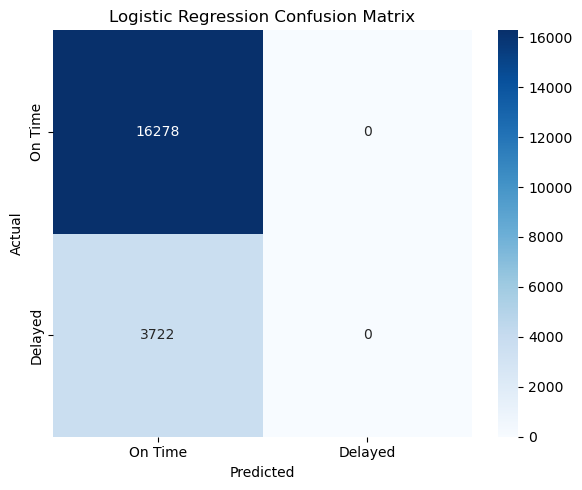

Saved!


In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# Predict
y_pred_lr = lr.predict(X_test_scaled)

# Evaluate
print("=== Logistic Regression ===")
print("Accuracy: {:.4f}".format(accuracy_score(y_test, y_pred_lr)))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['On Time', 'Delayed'],  zero_division=0))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['On Time', 'Delayed'],
            yticklabels=['On Time', 'Delayed'])
ax.set_title('Logistic Regression Confusion Matrix')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('lr_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

### Logistic Regression — Initial Result

The initial model achieves 81.4% accuracy but predicts "On Time" for every single flight, 
as confirmed by the confusion matrix. This is the majority class problem — since 81.4% 
of flights are on time, always predicting "On Time" yields high accuracy but zero 
predictive power for delays. The recall for delayed flights is 0.00, meaning the model 
fails to identify a single delay.

We address this by setting class_weight='balanced', which instructs the model to 
penalize misclassified delayed flights more heavily during training.

=== Logistic Regression (Balanced) ===
Accuracy: 0.5803

Classification Report:
              precision    recall  f1-score   support

     On Time       0.86      0.58      0.69     16278
     Delayed       0.24      0.60      0.35      3722

    accuracy                           0.58     20000
   macro avg       0.55      0.59      0.52     20000
weighted avg       0.75      0.58      0.63     20000



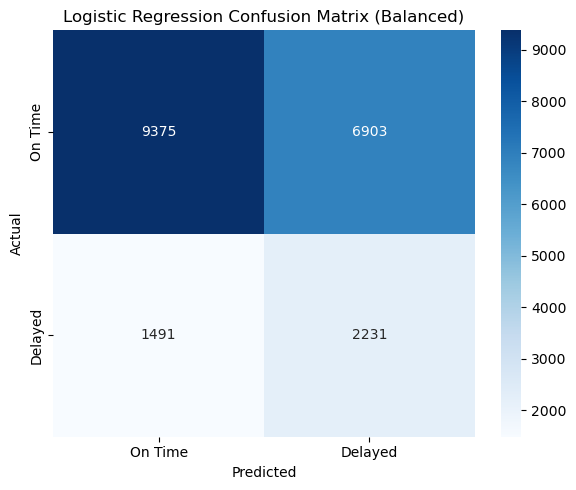

Saved!


In [32]:
# Train Logistic Regression with class weighting to handle imbalance
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_scaled, y_train)

# Predict
y_pred_lr = lr.predict(X_test_scaled)

# Evaluate
print("=== Logistic Regression (Balanced) ===")
print("Accuracy: {:.4f}".format(accuracy_score(y_test, y_pred_lr)))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['On Time', 'Delayed']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['On Time', 'Delayed'],
            yticklabels=['On Time', 'Delayed'])
ax.set_title('Logistic Regression Confusion Matrix (Balanced)')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('lr_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

### Logistic Regression — Balanced Result

With class balancing applied, the model now successfully identifies delayed flights. 
Accuracy drops to 58% but recall for delayed flights rises to 60%, meaning the model 
correctly identifies 6 out of 10 actual delays. Precision for delayed flights is 24%, 
indicating a high rate of false positives — flights predicted as delayed that arrived 
on time. This precision-recall tradeoff is expected given the class imbalance.

=== Naive Bayes ===
Accuracy: 0.8133

Classification Report:
              precision    recall  f1-score   support

     On Time       0.81      1.00      0.90     16278
     Delayed       0.16      0.00      0.00      3722

    accuracy                           0.81     20000
   macro avg       0.49      0.50      0.45     20000
weighted avg       0.69      0.81      0.73     20000



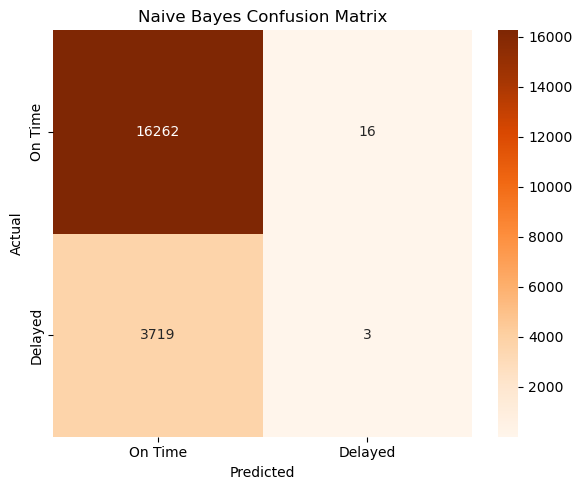

Saved!


In [33]:
from sklearn.naive_bayes import GaussianNB

# Train Naive Bayes
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

# Predict
y_pred_nb = nb.predict(X_test_scaled)

# Evaluate
print("=== Naive Bayes ===")
print("Accuracy: {:.4f}".format(accuracy_score(y_test, y_pred_nb)))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, target_names=['On Time', 'Delayed']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['On Time', 'Delayed'],
            yticklabels=['On Time', 'Delayed'])
ax.set_title('Naive Bayes Confusion Matrix')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('nb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

### Naive Bayes — Initial Result

Naive Bayes suffers from the same majority class problem as the initial Logistic 
Regression model, predicting nearly every flight as "On Time" and correctly identifying 
only 3 delayed flights out of 3,722. Unlike Logistic Regression, Naive Bayes does not 
support a class_weight parameter. Instead, we adjust the class priors to 50/50 to 
force more balanced predictions. 

=== Naive Bayes (Balanced Priors) ===
Accuracy: 0.5576

Classification Report:
              precision    recall  f1-score   support

     On Time       0.87      0.54      0.66     16278
     Delayed       0.24      0.64      0.35      3722

    accuracy                           0.56     20000
   macro avg       0.55      0.59      0.51     20000
weighted avg       0.75      0.56      0.61     20000



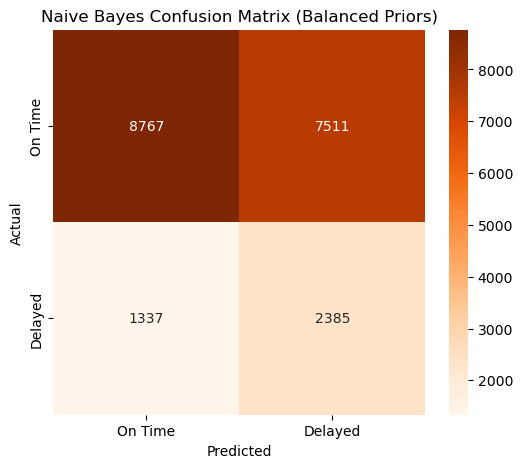

In [37]:
from sklearn.naive_bayes import GaussianNB
import numpy as np

# Naive Bayes doesn't have class_weight, so we manually set priors
delayed_rate = y_train.mean()
ontime_rate = 1 - delayed_rate

nb_balanced = GaussianNB(priors=[ontime_rate, delayed_rate])

# Adjust priors to force more balanced predictions
nb_balanced = GaussianNB(priors=[0.5, 0.5])
nb_balanced.fit(X_train_scaled, y_train)

y_pred_nb = nb_balanced.predict(X_test_scaled)

print("=== Naive Bayes (Balanced Priors) ===")
print("Accuracy: {:.4f}".format(accuracy_score(y_test, y_pred_nb)))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, target_names=['On Time', 'Delayed']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['On Time', 'Delayed'],
            yticklabels=['On Time', 'Delayed'])
ax.set_title('Naive Bayes Confusion Matrix (Balanced Priors)')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout
plt.savefig('nb_confusion_matrix.png', dpi=150, bbox_inches='tight')

### Naive Bayes — Balanced Result

With equal priors applied, Naive Bayes now identifies delayed flights more effectively. 
It achieves 56% accuracy with 64% recall for delayed flights — slightly higher recall 
than Logistic Regression but lower overall accuracy. Like Logistic Regression, precision 
for delayed flights remains low at 24%, reflecting the difficulty of the class imbalance 
problem with these features.

In [38]:
# ---- Model Comparison Summary ----
print("=" * 55)
print(f"{'Model':<30} {'Accuracy':>8} {'Recall (Delayed)':>15}")
print("=" * 55)
print(f"{'Logistic Regression (initial)':<30} {'0.8139':>8} {'0.00':>15}")
print(f"{'Logistic Regression (balanced)':<30} {'0.5803':>8} {'0.60':>15}")
print(f"{'Naive Bayes (initial)':<30} {'0.8133':>8} {'0.00':>15}")
print(f"{'Naive Bayes (balanced)':<30} {'0.5576':>8} {'0.64':>15}")
print("=" * 55)

Model                          Accuracy Recall (Delayed)
Logistic Regression (initial)    0.8139            0.00
Logistic Regression (balanced)   0.5803            0.60
Naive Bayes (initial)            0.8133            0.00
Naive Bayes (balanced)           0.5576            0.64


## Results & Comparison

Both models initially failed to predict any delays due to class imbalance. After applying 
balancing techniques, both achieved similar performance. Logistic Regression performed 
slightly better overall with 58% accuracy and 60% recall on delayed flights. Naive Bayes 
achieved slightly higher recall at 64% but lower accuracy at 56%.

Neither model achieves strong precision for delayed flights, suggesting that the features 
available at scheduling time — such as airline, airport, and scheduled times — have 
limited predictive power on their own. More sophisticated models such as Random Forest 
or gradient boosting, or the addition of weather and historical delay features, would 
likely yield better results.

## Conclusions

In this project we built a flight delay prediction pipeline using 2015 U.S. domestic 
flight data. We explored the dataset, identified and handled class imbalance, and trained 
two binary classification models — Logistic Regression and Naive Bayes — to predict 
whether a flight would be delayed by 15 or more minutes.

Both models demonstrated the importance of accounting for class imbalance in real-world 
datasets. A naive model that always predicts the majority class can achieve high accuracy 
while being completely useless in practice. By applying class balancing techniques we 
were able to build models that meaningfully identify delayed flights.

Through this project we learned that accuracy alone is a poor metric for imbalanced 
classification problems, and that precision, recall, and F1-score provide a more complete 
picture of model performance. We also learned that feature selection — particularly 
avoiding data leakage by using only pre-departure information — is a critical step in 
building a valid machine learning pipeline.